# Benchmark Analysis

Grouped bar chart comparing average total time (compile + run) across languages.

Each language group has three bars:
- **Local** — native toolchain runs
- **Engine (cold)** — first engine run (cold start)
- **Engine (subsequent)** — later engine runs after warm-up

Enter raw iteration timings (ms) in the data cells below; averages are computed automatically.

In [104]:
import seaborn as sns

# Use seaborn theme for plots
sns.set_theme(style="whitegrid")

import matplotlib.pyplot as plt
import os
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
})

DOCS = Path.cwd()

# Ensure the figures/ directory exists
os.makedirs("figures", exist_ok=True)
FIGURES = DOCS / "figures"

# Set font sizes for research paper
BIG_TITLE = 40
AXIS_LABEL = 32
TICK_LABEL = 32
LEGEND = 20
BAR_LABEL = 20

FLARE = sns.color_palette("flare", 7)
LOCAL_COLOR = FLARE[0]
ENGINE_COLOR = FLARE[2]
ENGINE_HATCH = "//"


In [89]:
from __future__ import annotations

import json

import numpy as np

REPO = DOCS.parent
OUTPUT_DIR = REPO / "tools" / "benchmarks" / "output"

LANGUAGES = ["cpp", "python", "rust"]

# Matches tools/benchmarks/lib/engine-toolchain.ts
CLANG_VERSION = "22.1.0"
PYTHON_VERSION = "3.11.3"
RUSTC_VERSION = "1.96.0"

TOOLCHAIN_LABELS = {
    "cpp": f"clang v{CLANG_VERSION}",
    "python": f"python v{PYTHON_VERSION}",
    "rust": f"rustc v{RUSTC_VERSION}",
}


def avg(values: list[float]) -> float:
    if not values:
        return float("nan")
    return sum(values) / len(values)


def load_local_iterations() -> dict[str, list[float]]:
    """Seed local iteration lists from the latest benchmark reports."""
    iterations: dict[str, list[float]] = {}
    for lang in LANGUAGES:
        reports = sorted(OUTPUT_DIR.glob(f"{lang}-*.json"), reverse=True)
        if not reports:
            raise FileNotFoundError(f"no benchmark report found for {lang} in {OUTPUT_DIR}")
        report = json.loads(reports[0].read_text())
        iterations[lang] = [point["totalMs"] for point in report["programs"][0]["dataPoints"]]
    return iterations


def series_averages(data: dict[str, list[float]]) -> dict[str, float]:
    return {lang: avg(data[lang]) for lang in LANGUAGES}


### Local iteration data

Total time in ms for each local run. Pre-filled from the latest reports; edit directly if needed.

In [90]:
local_total_ms = load_local_iterations()

# Example shape:
# local_total_ms = {
#     "cpp": [679.6, 677.3, ...],
#     "python": [37.4, 16.3, ...],
#     "rust": [748.5, 229.5, ...],
# }

local_avg_total_ms = series_averages(local_total_ms)
local_avg_total_ms


{'cpp': 585.7424874999999, 'python': 18.311125, 'rust': 269.68085840000003}

### Engine cold-start iteration data

Total time in ms for first-time / cold engine runs. Enter one or more values per language.

In [91]:
engine_cold_total_ms: dict[str, list[float]] = {
    "cpp": [9954, 9189, 9597, 9248, 10074, 9473, 10144, 9418, 9780, 9451],
    "python": [5031, 4770, 4736, 4707, 5105, 4606, 4606, 4548, 4617, 4561],
    "rust": [16593, 13904, 14030, 13729, 13721, 13721, 13563, 13625, 13726, 14249],
}

engine_cold_avg_total_ms = series_averages(engine_cold_total_ms)
engine_cold_avg_total_ms


{'cpp': 9632.8, 'python': 4728.7, 'rust': 14086.1}

### Engine subsequent-run iteration data

Total time in ms for warmed-up engine runs (e.g. iterations 2–10).

In [92]:
engine_subsequent_total_ms: dict[str, list[float]] = {
    "cpp": [815, 819, 868, 922, 818, 816, 817, 822, 822, 820],
    "python": [414, 376, 387, 374, 423, 381, 381, 386, 373, 365],
    "rust": [1330, 1277, 1233, 1225, 1234, 1276, 1228, 1279, 1228, 1281],
}

engine_subsequent_avg_total_ms = series_averages(engine_subsequent_total_ms)
engine_subsequent_avg_total_ms


{'cpp': 833.9, 'python': 386.0, 'rust': 1259.1}

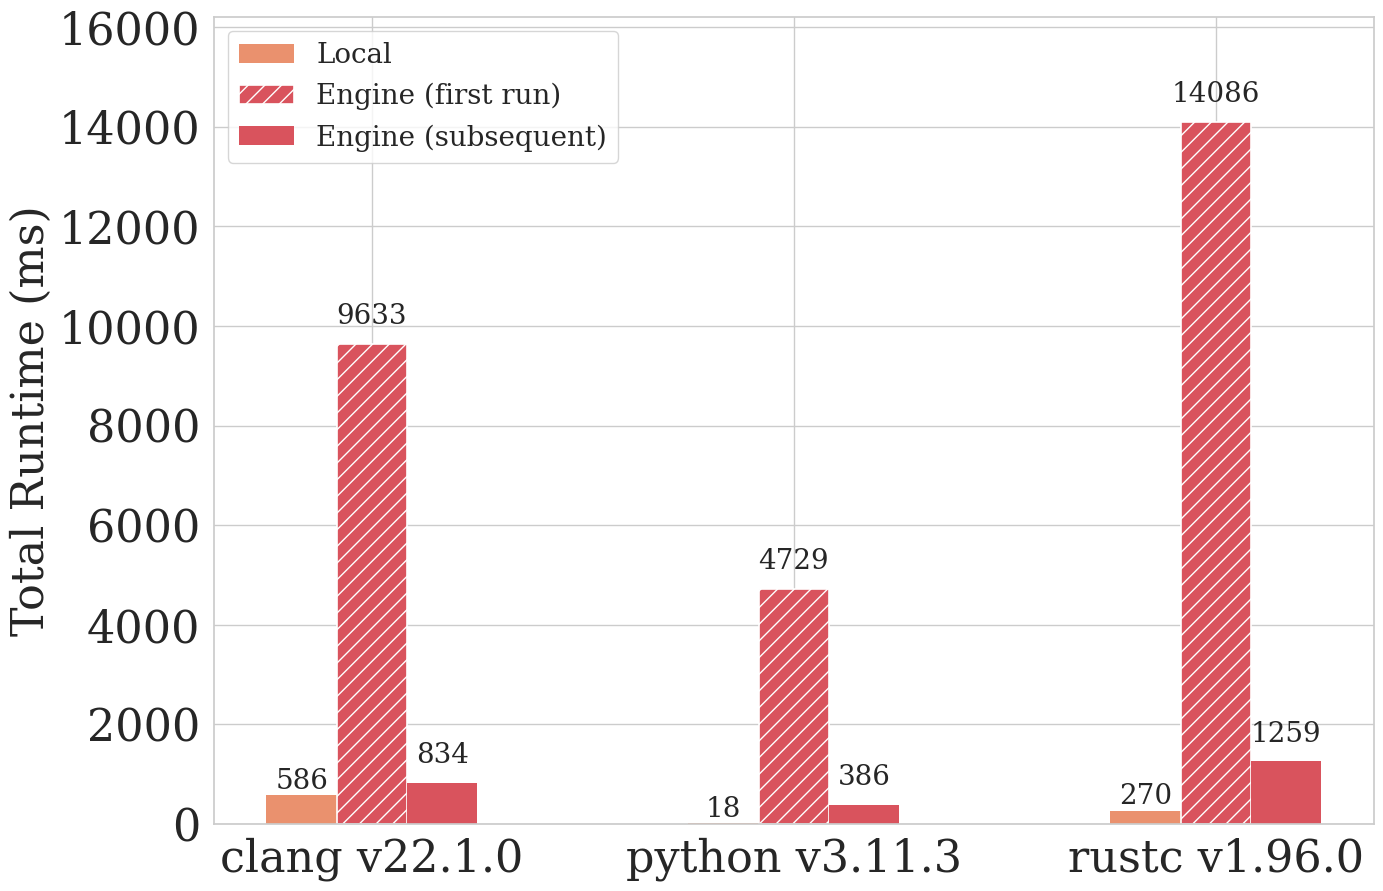

In [106]:
series = [
    ("Local", local_avg_total_ms, LOCAL_COLOR, None),
    ("Engine (first run)", engine_cold_avg_total_ms, ENGINE_COLOR, ENGINE_HATCH),
    ("Engine (subsequent)", engine_subsequent_avg_total_ms, ENGINE_COLOR, None),
]

x = np.arange(len(LANGUAGES))
bar_width = 0.5 / len(series)

fig, ax = plt.subplots(figsize=(14, 9))

plotted_max = 0.0
for i, (label, values, color, hatch) in enumerate(series):
    offset = (i - (len(series) - 1) / 2) * bar_width
    series_values = [values[lang] for lang in LANGUAGES]
    heights = [0.0 if np.isnan(v) else v for v in series_values]
    bars = ax.bar(
        x + offset,
        heights,
        bar_width,
        label=label,
        color=color,
        edgecolor="white" if hatch else color,
        hatch=hatch or "",
        linewidth=1.2 if hatch else 0,
    )
    plotted_max = max(plotted_max, max(heights, default=0.0))
    for bar, value in zip(bars, series_values):
        if np.isnan(value):
            continue
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (plotted_max * 0.02 if plotted_max else 1),
            f"{round(value)}",
            ha="center",
            va="bottom",
            fontsize=BAR_LABEL,
        )

ax.set_ylabel("Total Runtime (ms)", fontsize=AXIS_LABEL)
ax.set_xticks(x)
ax.set_xticklabels([TOOLCHAIN_LABELS[lang] for lang in LANGUAGES], fontsize=TICK_LABEL)
ax.tick_params(axis="y", labelsize=TICK_LABEL)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{int(value)}"))
legend = ax.legend(fontsize=LEGEND)
for patch, (_, _, color, hatch) in zip(legend.legend_handles, series):
    if hatch:
        patch.set_facecolor(color)
        patch.set_edgecolor("white")
        patch.set_hatch(hatch)
        patch.set_linewidth(1.2)
ax.set_ylim(0, plotted_max * 1.15 if plotted_max else 1)

plt.tight_layout()
fig.savefig(FIGURES / "benchmark-total.png", bbox_inches="tight", dpi=150)
plt.show()
